# Salt-free Ca data: affine Gaussian line fit

Fit the salt-free `D2O` data from the GRASP exports in `data/Ca` using one positive Gaussian radial $k$ distribution and a slight incompressible uniaxial affine stretch. The fourth data column is treated as the pointwise Gaussian resolution standard deviation $\sigma_Q$.

The nonlinear parameters are `mean_k`, the relative Gaussian width `r_sigma_k`, and the real-space axial stretch `stretch_ratio`. The transverse stretches are `stretch_ratio**(-1/2)`, so the deformation is volume preserving.

The measured intensity remains unchanged. During initial-model evaluation and fitting, every trial model is convolved with the pointwise Gaussian resolution before its scale and regression loss are calculated.

At every trial, the isotropic Gaussian line spectrum is evaluated over the full stretched-$Q$ support and powder averaged by Gauss--Legendre angular quadrature. The powder curve is then resolution smeared before its scale and regression loss are evaluated. No skewed, bimodal, or maximum-entropy $k$ distribution is used.

In [1]:
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def salt_concentration_mM(path):
    name = Path(path).name
    if re.search(r"D2O", name, flags=re.IGNORECASE):
        return 0.0
    match = re.search(r"(?P<value>\d+(?:\.\d+)?)mM(?:Ca)?IQ", name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f"Cannot parse Ca concentration from {name!r}")
    return float(match.group("value"))

def load_grasp_iq(path):
    rows = []
    for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        fields = line.split()
        if len(fields) != 4:
            continue
        try:
            rows.append(tuple(float(value) for value in fields))
        except ValueError:
            continue
    table = np.asarray(rows, dtype=float)
    if table.ndim != 2 or table.shape[0] < 8 or table.shape[1] != 4:
        raise ValueError(f"Could not find a four-column Q, I, error, dQ table in {path}")
    return table


## Select the dataset and model

For the first pass, change only `SERIES_KEY`, `MODEL_MODE`, and the centralized `PARAMETERS` table below. Keep `RUN_FIT = False` until the initial curve is satisfactory.

In [2]:
DATA_DIR = Path("data/Ca")
OUTPUT_DIR = Path("output/ca_aniso")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES_KEY = "D2O"
MODEL_MODE = "line_only"
K_DISTRIBUTION = "gaussian_radial"
LOCK_SALT_FEATURE_TO_D2O = False
REFERENCE_MEAN_K_OVERRIDE = None  # optional manual value in A^-1

FIT_Q_MIN = 6.0e-3
FIT_Q_MAX = 5.0e-1
HIGHQ_ANCHOR_MIN = 2.0e-1
SUBTRACT_BG = True
HIGHQ_ANCHOR_WEIGHT = 1.0
LOG_ERROR_FLOOR = 0.04
FIT_GUIDANCE_TAG = "unguided_gaussian_affine_powder"

# Forward resolution smearing. The fourth data column is sigma_Q.
SMEAR_MODEL = True

files = sorted(DATA_DIR.glob("*.dat"), key=lambda path: salt_concentration_mM(path))
if not files:
    raise FileNotFoundError(f"No .dat files found under {DATA_DIR}")

SERIES = {}
for path in files:
    concentration = salt_concentration_mM(path)
    key = "D2O" if concentration == 0.0 else f"{concentration:g}mM"
    if key in SERIES:
        raise ValueError(f"Duplicate CA series key {key!r}")
    SERIES[key] = {"file": path, "concentration_mM": concentration}

if SERIES_KEY not in SERIES:
    raise KeyError(f"SERIES_KEY must be one of {tuple(SERIES)}")
if MODEL_MODE not in {"heterogeneous", "line_only"}:
    raise ValueError("MODEL_MODE must be 'heterogeneous' or 'line_only'")
if K_DISTRIBUTION != "gaussian_radial":
    raise ValueError("This notebook intentionally uses only gaussian_radial")

config = SERIES[SERIES_KEY]
DATA_FILE = config["file"]
SALT_MILLIMOLAR = float(config["concentration_mM"])
IS_SALT_FREE = SALT_MILLIMOLAR == 0.0
SAMPLE_TAG = "ca_D2O" if IS_SALT_FREE else f"ca_{SALT_MILLIMOLAR:g}mM"
SERIES_LABEL = "D2O (0 mM Ca)" if IS_SALT_FREE else f"{SALT_MILLIMOLAR:g} mM Ca"
CF_MODEL_MODE = MODEL_MODE
FIT_VARIANT_TAG = f"{MODEL_MODE}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}"

print("[series]", {key: item["file"].name for key, item in SERIES.items()})
print(f"[status] selected={SERIES_LABEL}, mode={MODEL_MODE}, k_distribution={K_DISTRIBUTION}")
print(f"[status] data={DATA_FILE}")

[series] {'D2O': 'PSS_67K_D2OIQ_362051_d01_c01.dat', '1mM': 'PSS_67K_1mMCaIQ_362054_d04_c01.dat', '10mM': 'PSS_67K_10mMCaIQ_362053_d03_c01.dat', '24mM': 'PSS_67k_24mMCaIQ_362130_d01_c01.dat', '100mM': 'PSS_67K_100mMCaIQ_362052_d02_c01.dat'}
[status] selected=D2O (0 mM Ca), mode=line_only, k_distribution=gaussian_radial
[status] data=data\Ca\PSS_67K_D2OIQ_362051_d01_c01.dat


## Load and inspect the complete concentration series

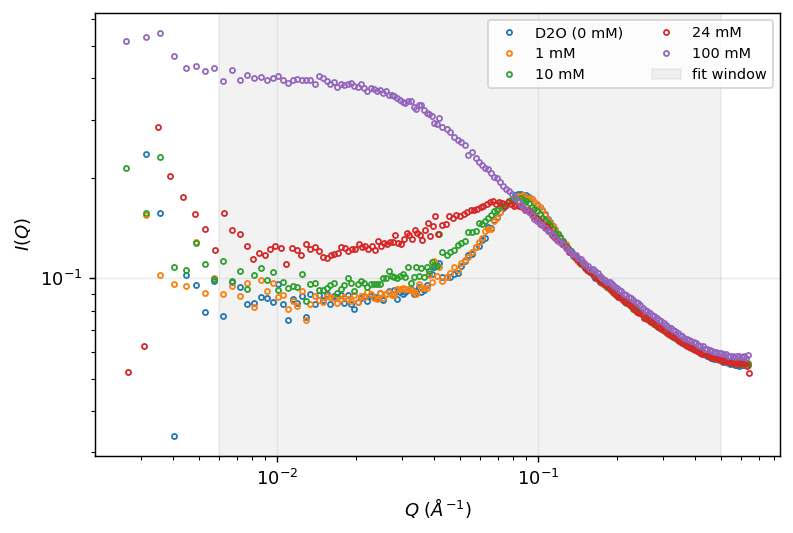

[status] loaded 186 measured points; fit Q=[0.006, 0.5]
[resolution] forward model smearing=enabled


In [3]:
all_tables = {key: load_grasp_iq(item["file"]) for key, item in SERIES.items()}
table = all_tables[SERIES_KEY]
q, intensity, error, dq = (np.asarray(table[:, col], dtype=float) for col in range(4))
good = np.isfinite(q) & np.isfinite(intensity) & np.isfinite(error) & np.isfinite(dq) & (q > 0) & (error > 0) & (dq > 0)
order = np.argsort(q[good])
q, intensity, error, dq = (array[good][order] for array in (q, intensity, error, dq))

profile = cf.RadialProfile(
    label=SAMPLE_TAG,
    q=q,
    intensity=intensity,
    error=error,
    count=np.ones(q.size, dtype=int),
)
fit_q_min = max(float(q.min()), FIT_Q_MIN)
fit_q_max = min(float(q.max()), FIT_Q_MAX)
HIGHQ_ANCHOR_BOUNDS = (max(HIGHQ_ANCHOR_MIN, fit_q_min), fit_q_max)
regression_weights = np.ones_like(q)

np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_observation.csv",
    np.column_stack([q, intensity, error, dq]),
    delimiter=",",
    header="Q,I,err,dQ",
    comments="",
)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for key, item in SERIES.items():
    values = all_tables[key]
    positive = values[:, 1] > 0
    label = "D2O (0 mM)" if item["concentration_mM"] == 0 else f"{item['concentration_mM']:g} mM"
    ax.loglog(values[positive, 0], values[positive, 1], "o", ms=2.8, markerfacecolor="none", label=label)
ax.axvspan(fit_q_min, fit_q_max, color="k", alpha=0.05, label="fit window")
ax.set_xlabel(r"$Q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ca_raw_series.png")
plt.show()
print(f"[status] loaded {q.size} measured points; fit Q=[{fit_q_min:.6g}, {fit_q_max:.6g}]")
print(f"[resolution] forward model smearing={'enabled' if SMEAR_MODEL else 'disabled'}")

## Background and high-$Q$ line anchor

Only the high-$Q$ $C/Q+B$ anchor is used. The low-$Q$ upturn is assumed negligible, so no DAB or $Q^{-4}$ anchor enters the fit.

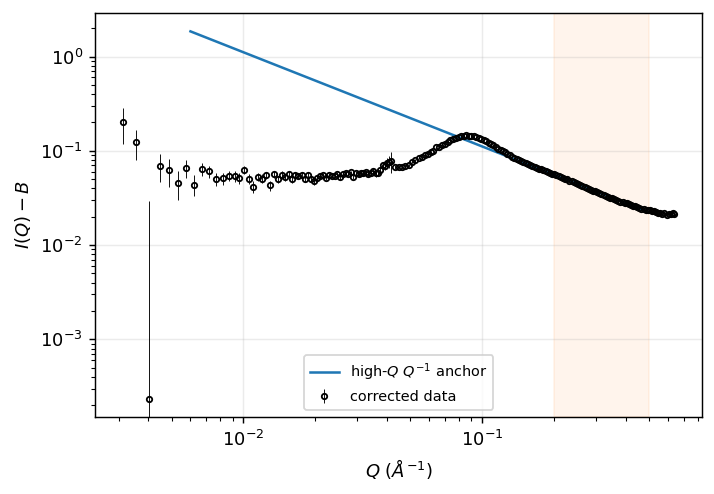

[background] subtracted B=0.033386664
[anchor] high-Q coefficient=0.011107407


In [4]:
raw_highq_fit = cf.fit_highq_line_anchor(profile, HIGHQ_ANCHOR_BOUNDS, allow_signed_background=True)
background_subtracted = raw_highq_fit.parameters["background"] if SUBTRACT_BG else 0.0
working_profile = cf.subtract_constant_background(profile, background_subtracted) if SUBTRACT_BG else profile
highq_line_fit = cf.fit_highq_line_anchor(
    working_profile,
    HIGHQ_ANCHOR_BOUNDS,
    background_max=0.0 if SUBTRACT_BG else None,
)

np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_background_corrected_observation.csv",
    cf.profile_table(working_profile),
    delimiter=",",
    header="Q,I,err,count",
    comments="",
)
with (OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_guesses.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["name", "value_1", "value_2", "background", "relative_rmse"])
    writer.writerow(["subtracted_background", background_subtracted, np.nan, np.nan, np.nan])
    writer.writerow(["highQ_line", highq_line_fit.parameters["coefficient"], highq_line_fit.parameters["rho0_apparent"], highq_line_fit.parameters["background"], highq_line_fit.relative_rmse])

positive = working_profile.intensity > 0
q_grid = np.geomspace(fit_q_min, fit_q_max, 500)
fig, ax = plt.subplots(figsize=(5.6, 3.9))
ax.errorbar(working_profile.q[positive], working_profile.intensity[positive], yerr=working_profile.error[positive], fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label="corrected data")
ax.plot(q_grid, cf.evaluate_anchor_fit(highq_line_fit, q_grid), lw=1.4, label=r"high-$Q$ $Q^{-1}$ anchor")
ax.axvspan(*HIGHQ_ANCHOR_BOUNDS, color="C1", alpha=0.08)
ax.set(xscale="log", yscale="log", xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I(Q)-B$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_highq_anchor.png")
plt.show()
print(f"[background] subtracted B={background_subtracted:.8g}")
print(f"[anchor] high-Q coefficient={highq_line_fit.parameters['coefficient']:.8g}")

## Centralized fit controls

Each parameter has exactly one row containing its initial value, bounds, and fixed/free state. In `line_only` mode, `k_H_over_k` and `b` are removed automatically. For salt-containing samples, `mean_k` is automatically replaced and fixed by the D2O fit when locking is enabled.

In [17]:
# Edit this table while manually tuning the D2O initial model.
PARAMETERS = {
    "mean_k":      {"initial": 0.050,  "bounds": (0.010, 0.50), "fixed": False},
    "r_sigma_k":   {"initial": 0.17,   "bounds": (0.10, 1.20),  "fixed": False},
    "stretch_ratio": {"initial": 1.4, "bounds": (0.60, 1.60),  "fixed": False},
    "k_H_over_k":  {"initial": 5e-5,   "bounds": (1e-6, 1e-2), "fixed": True},
    "b":           {"initial": -2.0,   "bounds": (-4.0, -0.5), "fixed": True},
}

REFERENCE_PARAMETER_FILE = OUTPUT_DIR / f"ca_D2O_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv"
reference_mean_k = REFERENCE_MEAN_K_OVERRIDE
if not IS_SALT_FREE and LOCK_SALT_FEATURE_TO_D2O and reference_mean_k is None:
    if not REFERENCE_PARAMETER_FILE.exists():
        raise FileNotFoundError(
            f"Fit D2O first or set REFERENCE_MEAN_K_OVERRIDE; missing {REFERENCE_PARAMETER_FILE}"
        )
    reference_values = {}
    with REFERENCE_PARAMETER_FILE.open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            reference_values[row["name"]] = float(row["value"])
    reference_mean_k = reference_values["mean_k"]

if not IS_SALT_FREE and LOCK_SALT_FEATURE_TO_D2O:
    PARAMETERS["mean_k"]["initial"] = float(reference_mean_k)
    PARAMETERS["mean_k"]["fixed"] = True

distribution_names = ["r_sigma_k"]
active_names = ["mean_k", *distribution_names, "stretch_ratio"]
if CF_MODEL_MODE == "heterogeneous":
    active_names += ["k_H_over_k", "b"]
fit_initial = {name: float(PARAMETERS[name]["initial"]) for name in active_names}
fit_bounds = {name: tuple(map(float, PARAMETERS[name]["bounds"])) for name in active_names}
FIXED_PARAMETERS = {name: fit_initial[name] for name in active_names if PARAMETERS[name]["fixed"]}

fit_distribution_parameter_set = {
    name: {"initial": fit_initial[name], "bounds": fit_bounds[name]}
    for name in distribution_names
}
fit_model_settings = {
    "k_distribution": K_DISTRIBUTION,
    "regression_loss": "relative",
    "num_modes_k": 2**10,
    "k_sampling": "quadrature",
    "Nr": 3000,
    "Nr_small": 600,
    "N_samp_U": 2**12,
    "N_samp_st": 2**7,
    "NQ": 220,
    "r_min_factor": 1e-3,
    "r_split_factor": 5.0,
    "r_max_factor": 250.0,
    "powder_n_mu": 64,
    "progress": False,
}

print("[parameters]")
for name in active_names:
    state = "fixed" if name in FIXED_PARAMETERS else "free"
    print(f"  {name:16s} initial={fit_initial[name]:.8g} bounds={fit_bounds[name]} {state}")
if reference_mean_k is not None:
    print(f"[reference] mean_k={reference_mean_k:.8g} A^-1, wavelength={2*np.pi/reference_mean_k:.8g} A")

[parameters]
  mean_k           initial=0.05 bounds=(0.01, 0.5) free
  r_sigma_k        initial=0.17 bounds=(0.1, 1.2) free
  stretch_ratio    initial=1.4 bounds=(0.6, 1.6) free


## Inspect the resolution-smeared initial model

[status] initial cost=174.373
[status] p_H=1
[feature] wavelength=125.66371 A
[affine] stretch_ratio=1.4; transverse=0.84515425
[high-Q] log-log slope unsmeared=-1.0029, smeared=-0.9813


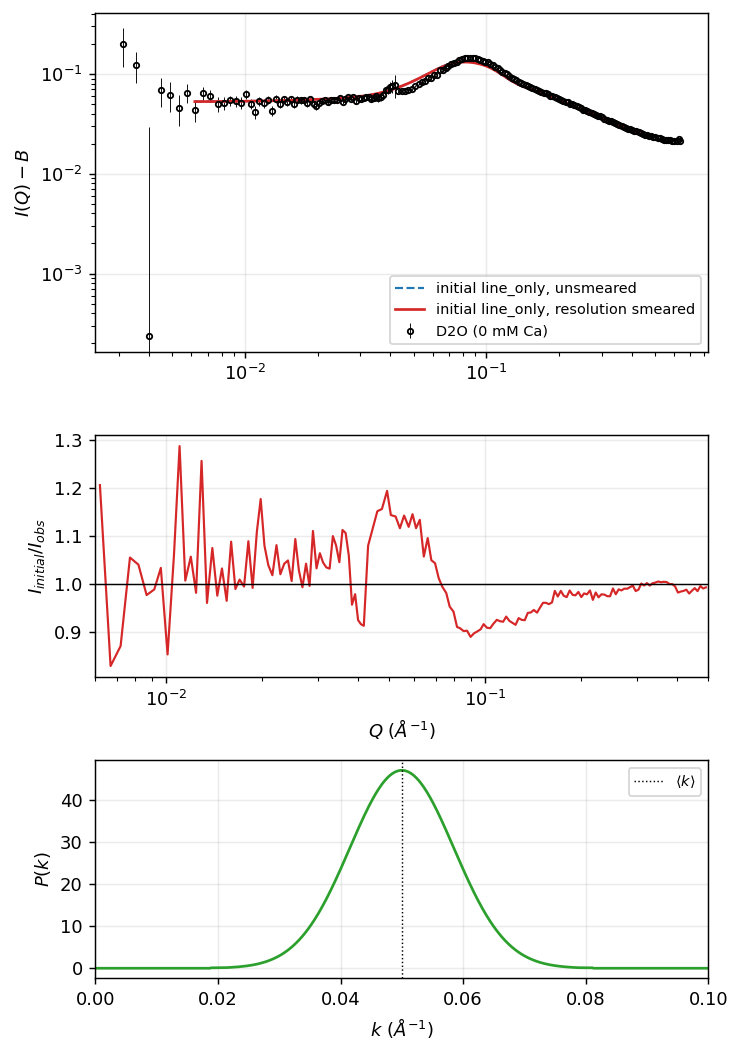

In [18]:
initial_model_unsmeared = cf.evaluate_heterogeneous_line_guess(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    parameters=fit_initial,
    model_mode=CF_MODEL_MODE,
    resolution_sigma=None,
    regression_weights=regression_weights,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=LOG_ERROR_FLOOR,
    affine_stretch=True,
)
initial_model = cf.evaluate_heterogeneous_line_guess(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    parameters=fit_initial,
    model_mode=CF_MODEL_MODE,
    resolution_sigma=dq if SMEAR_MODEL else None,
    regression_weights=regression_weights,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=LOG_ERROR_FLOOR,
    affine_stretch=True,
)
print(f"[status] initial cost={initial_model.cost:.6g}")
print(f"[status] p_H={initial_model.parameters['p_H']:.10g}")
print(f"[feature] wavelength={2*np.pi/initial_model.parameters['mean_k']:.8g} A")
print(f"[affine] stretch_ratio={initial_model.parameters['stretch_ratio']:.8g}; transverse={initial_model.parameters['stretch_ratio']**-0.5:.8g}")
tail = initial_model.q >= HIGHQ_ANCHOR_MIN
if np.count_nonzero(tail) >= 3:
    slope_unsmeared = np.polyfit(np.log(initial_model_unsmeared.q[tail]), np.log(initial_model_unsmeared.model[tail]), 1)[0]
    slope_smeared = np.polyfit(np.log(initial_model.q[tail]), np.log(initial_model.model[tail]), 1)[0]
    print(f"[high-Q] log-log slope unsmeared={slope_unsmeared:.4f}, smeared={slope_smeared:.4f}")

k_initial, p_k_initial = cf.radial_k_distribution_density(
    mean_k=initial_model.parameters["mean_k"],
    r_sigma_k=initial_model.parameters["r_sigma_k"],
    skewness=initial_model.parameters.get("skewness", 0.0),
    k_distribution=K_DISTRIBUTION,
    distribution_parameters={name: initial_model.parameters[name] for name in distribution_names},
)
fig, axes = plt.subplots(3, 1, figsize=(5.8, 8.2), gridspec_kw={"height_ratios": [1.4, 1.0, 0.9]})
positive = working_profile.intensity > 0
axes[0].errorbar(working_profile.q[positive], working_profile.intensity[positive], yerr=working_profile.error[positive], fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label=SERIES_LABEL)
axes[0].plot(initial_model_unsmeared.q, initial_model_unsmeared.model, "--", color="C0", lw=1.2, label=f"initial {MODEL_MODE}, unsmeared")
axes[0].plot(initial_model.q, initial_model.model, color="C3", lw=1.5, label=f"initial {MODEL_MODE}, resolution smeared")
axes[0].set(xscale="log", yscale="log", ylabel=r"$I(Q)-B$")
axes[0].legend(fontsize=8)
axes[1].semilogx(initial_model.q, initial_model.model / initial_model.intensity, color="C3", lw=1.2)
axes[1].axhline(1.0, color="k", lw=0.8)
axes[1].set(xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I_{initial}/I_{obs}$", xlim=(fit_q_min, fit_q_max))
axes[2].plot(k_initial, p_k_initial, color="C2", lw=1.5)
axes[2].axvline(initial_model.parameters["mean_k"], color="k", lw=0.8, ls=":", label=r"$\langle k\rangle$")
axes[2].set(xlabel=r"$k$ ($\AA^{-1}$)", ylabel=r"$P(k)$", xlim=(0.0, 2.0 * initial_model.parameters["mean_k"]))
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_initial.png")
plt.show()

## Run the fit when ready

Leave `RUN_FIT = False` while inspecting the salt-free initial model. Set it to `True` only when you are ready to run the three-parameter Gaussian--affine fit.

In [19]:
RUN_FIT = True
MAX_NFEV = 100

if RUN_FIT:
    line_fit = cf.fit_heterogeneous_line_least_squares(
        working_profile,
        q_bounds=(fit_q_min, fit_q_max),
        initial=fit_initial,
        model_mode=CF_MODEL_MODE,
        resolution_sigma=dq if SMEAR_MODEL else None,
        regression_weights=regression_weights,
        lowq_kappa_anchor=None,
        highq_coefficient_anchor=highq_line_fit.parameters["coefficient"],
        bounds=fit_bounds,
        model_settings=fit_model_settings,
        distribution_parameter_set=fit_distribution_parameter_set,
        fixed_parameters=FIXED_PARAMETERS,
        max_nfev=MAX_NFEV,
        anchor_weight=HIGHQ_ANCHOR_WEIGHT,
        log_error_floor=LOG_ERROR_FLOOR,
        affine_stretch=True,
    )
    line_fit.parameters["feature_wavelength_A"] = 2 * np.pi / line_fit.parameters["mean_k"]
    line_fit.parameters["salt_concentration_mM"] = SALT_MILLIMOLAR
    print(f"[status] success={line_fit.success}, nfev={line_fit.nfev}, cost={line_fit.cost:.6g}")
    print(f"[status] {line_fit.message}")
    for name, value in line_fit.parameters.items():
        print(f"  {name:24s} {value:.10g}")

    with (OUTPUT_DIR / f"{SAMPLE_TAG}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(["name", "value"])
        writer.writerows(line_fit.parameters.items())
    np.savetxt(
        OUTPUT_DIR / f"{SAMPLE_TAG}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_curve.csv",
        np.column_stack([line_fit.q, line_fit.intensity, line_fit.error, line_fit.model, line_fit.model / line_fit.intensity]),
        delimiter=",",
        header="Q,I_obs,err,I_fit_smeared,I_fit_smeared_over_I_obs",
        comments="",
    )
else:
    print("[status] fit not run; tune the centralized parameter table and inspect the initial model")

[status] success=True, nfev=15, cost=47.5442
[status] `xtol` termination condition is satisfied.
  scale                    12.23818308
  mean_k                   0.05169305115
  r_sigma_k                0.1651028259
  k_H_over_k               0
  b                        -inf
  k_H                      0
  p_H                      1
  sigma_H_squared          0
  alpha_H                  0
  kappa_H                  0
  rho0                     0.0002912450118
  stretch_ratio            1.227221937
  highq_coefficient        0.01110351336
  feature_wavelength_A     121.5479676
  salt_concentration_mM    0


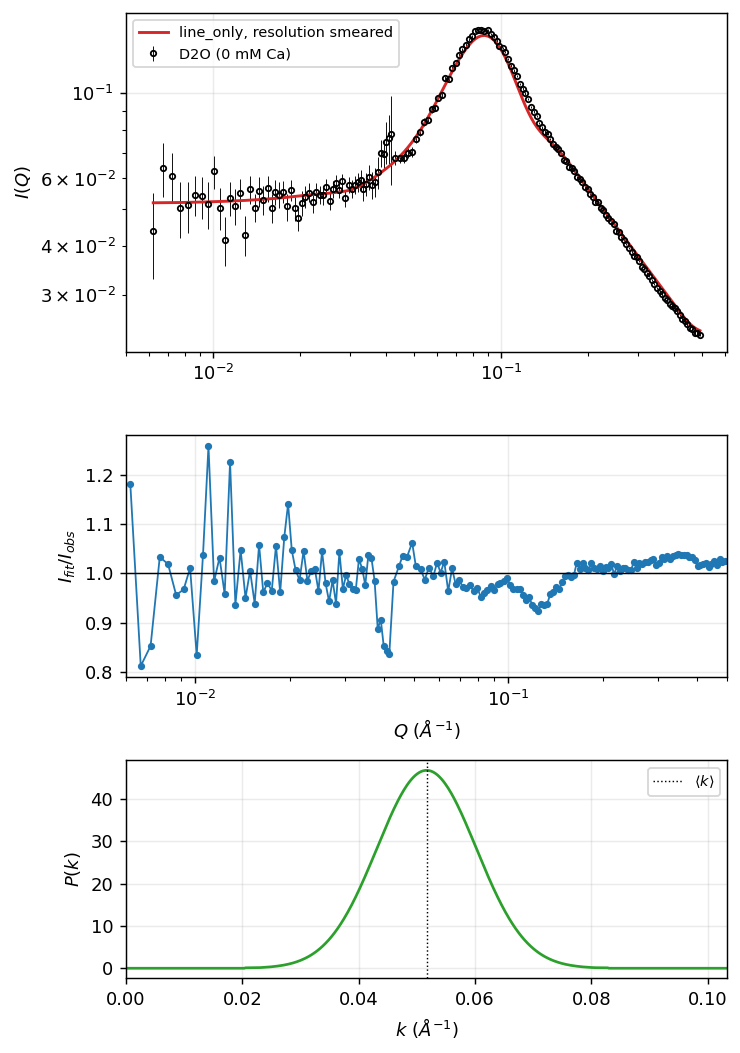

In [20]:
if RUN_FIT:
    k_fit, p_k_fit = cf.radial_k_distribution_density(
        mean_k=line_fit.parameters["mean_k"],
        r_sigma_k=line_fit.parameters["r_sigma_k"],
        skewness=line_fit.parameters.get("skewness", 0.0),
        k_distribution=K_DISTRIBUTION,
        distribution_parameters={name: line_fit.parameters[name] for name in distribution_names},
    )
    fig, axes = plt.subplots(3, 1, figsize=(5.8, 8.2), gridspec_kw={"height_ratios": [1.4, 1.0, 0.9]})
    axes[0].errorbar(line_fit.q, line_fit.intensity, yerr=line_fit.error, fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label=SERIES_LABEL)
    axes[0].plot(line_fit.q, line_fit.model, color="C3", lw=1.6, label=f"{MODEL_MODE}, resolution smeared")
    axes[0].set(xscale="log", yscale="log", ylabel=r"$I(Q)$")
    axes[0].legend(fontsize=8)
    axes[1].semilogx(line_fit.q, line_fit.model / line_fit.intensity, "o-", ms=3, lw=1)
    axes[1].axhline(1.0, color="k", lw=0.8)
    axes[1].set(xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I_{fit}/I_{obs}$", xlim=(fit_q_min, fit_q_max))
    axes[2].plot(k_fit, p_k_fit, color="C2", lw=1.5)
    axes[2].axvline(line_fit.parameters["mean_k"], color="k", lw=0.8, ls=":", label=r"$\langle k\rangle$")
    axes[2].set(xlabel=r"$k$ ($\AA^{-1}$)", ylabel=r"$P(k)$", xlim=(0.0, 2.0 * line_fit.parameters["mean_k"]))
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_fit.png")
    plt.show()